# Direct-binding Kd models

This notebook demonstrates `dir_simple`, `dir_specific`, and `dir_total` using synthetic data.

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bindcurve as bc

## Helper for synthetic data

In [23]:
data_all = bc.DoseResponseData.from_csv(
    "tutorial_data/synthetic/direct_binding_wide.csv", 
    format="wide",
)

## Simple direct binding

`dir_simple` assumes the x-axis is free receptor concentration.

In [24]:
simple_params = {'Kds': 1.5}
simple_data = bc.DoseResponseData(
    data_all.table[data_all.table['compound_id'] == 'cmpd_1'],
)
simple_results = bc.fit(simple_data, model='dir_simple')
simple_results.summary()

,compound_id,N_exp,N_obs,ymin,ymin_SD,ymin_SEM,ymin_CI95_lower,ymin_CI95_upper,ymax,ymax_SD,...,ymax_CI95_upper,Kds,Kds_SD_lower,Kds_SD_upper,Kds_SEM_lower,Kds_SEM_upper,Kds_CI95_lower,Kds_CI95_upper,R_squared,Chi_squared
0,cmpd_1,3,33,0.083322,0.167273,0.096575,-0.332207,0.49885,100.229439,0.272584,...,100.906575,0.030505,0.027702,0.033591,0.028854,0.03225,0.02401,0.038755,0.999671,18.666111


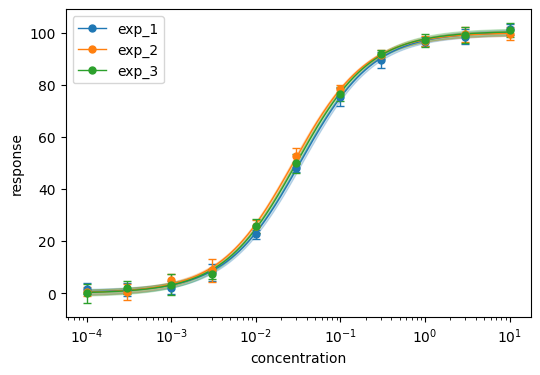

In [25]:
fig, ax = plt.subplots(figsize=(6, 4))
bc.plot_fits(simple_data, simple_results, ax=ax, confidence_band=True)
ax.set_xlabel("concentration")
ax.set_ylabel("response")
ax.legend()
plt.show()

## Specific direct binding with ligand depletion

`dir_specific` requires fixed total labeled ligand concentration `LsT`.

In [26]:
specific_data = bc.DoseResponseData(
    data_all.table[data_all.table['compound_id'] == 'cmpd_1'],
)
specific_results = bc.fit(
    specific_data,
    model='dir_specific',
    fixed={'LsT': 0.35},
)
specific_results.summary()

,compound_id,N_exp,N_obs,ymin,ymin_SD,ymin_SEM,ymin_CI95_lower,ymin_CI95_upper,ymax,ymax_SD,...,LsT_CI95_upper,Kds,Kds_SD_lower,Kds_SD_upper,Kds_SEM_lower,Kds_SEM_upper,Kds_CI95_lower,Kds_CI95_upper,R_squared,Chi_squared
0,cmpd_1,3,33,16.773632,0.883177,0.509903,14.579698,18.967565,102.970603,0.397279,...,0.35,8.489674e-12,1.633909e-13,4.411172e-10,8.676658e-13,8.306719e-11,4.644594e-16,1.551795e-07,0.852003,8391.055248


## Total direct binding with nonspecific term

`dir_total` requires fixed `LsT` and dimensionless nonspecific term `Ns`.

In [27]:
total_data = bc.DoseResponseData(
    data_all.table[data_all.table['compound_id'] == 'cmpd_1'],
)
total_results = bc.fit(
    total_data,
    model='dir_total',
    fixed={'LsT': 0.4, 'Ns': 0.25},
)
total_results.summary()

,compound_id,N_exp,N_obs,ymin,ymin_SD,ymin_SEM,ymin_CI95_lower,ymin_CI95_upper,ymax,ymax_SD,...,Ns_CI95_upper,Kds,Kds_SD_lower,Kds_SD_upper,Kds_SEM_lower,Kds_SEM_upper,Kds_CI95_lower,Kds_CI95_upper,R_squared,Chi_squared
0,cmpd_1,3,33,16.580165,0.889975,0.513827,14.369344,18.790986,104.197479,0.379466,...,0.25,3.147765e-08,3.115975e-09,3.179878e-07,8.281459e-09,1.196458e-07,1.006732e-10,0.00001,0.854508,8249.097107
